# Perfil da Camada Bronze — Atlas do Desenvolvimento Humano

Este notebook faz uma checagem rápida de qualidade e conteúdo dos dados
brutos baixados do Atlas do Desenvolvimento Humano no Brasil, antes de
seguirmos para a camada silver (limpeza + integração com a base da Fase 2).

Fonte: PNUD, IPEA e Fundação João Pinheiro — ver `data/bronze/README.md`
para detalhes completos de proveniência.


In [1]:
import pandas as pd
import json

pd.set_option("display.max_columns", 20)

BRONZE_DIR = "../data/bronze/atlas_desenvolvimento_humano"

df_mun = pd.read_csv(f"{BRONZE_DIR}/municipal_raw.csv", sep=";", decimal=",", encoding="utf-8")
df_dic = pd.read_csv(f"{BRONZE_DIR}/dicionario_raw.csv", sep=";", encoding="utf-8")

with open(f"{BRONZE_DIR}/_metadata.json", encoding="utf-8") as f:
    metadata = json.load(f)

print("Shape municipal:", df_mun.shape)
print("Anos disponíveis:", sorted(df_mun["ANO"].unique()))
metadata


Shape municipal: (16695, 237)
Anos disponíveis: [np.int64(1991), np.int64(2000), np.int64(2010)]


{'camada': 'bronze',
 'assunto': 'Atlas do Desenvolvimento Humano no Brasil (IDHM e indicadores associados)',
 'data_extracao_utc': '2026-08-21T20:14:34.604885+00:00',
 'autoria_dado_original': 'PNUD, IPEA e Fundação João Pinheiro',
 'site_oficial': 'http://www.atlasbrasil.org.br',
 'observacao': 'Dados baixados via réplica pública em CSV (github.com/mauriciocramos/IDHM), pois o ambiente de execução não tem acesso direto a atlasbrasil.org.br. Recomenda-se validar contra o arquivo oficial quando possível.',
 'arquivos': {'municipal_raw.csv': {'descricao': 'Indicadores municipais do Atlas do Desenvolvimento Humano (IDHM e componentes)',
   'url_replica': 'https://raw.githubusercontent.com/mauriciocramos/IDHM/main/municipal.csv',
   'url_oficial': 'http://www.atlasbrasil.org.br/2013/data/rawData/atlas2013_dadosbrutos_pt.xlsx',
   'linhas': 16695,
   'colunas': 237},
  'estadual_raw.csv': {'descricao': 'Indicadores estaduais do Atlas do Desenvolvimento Humano',
   'url_replica': 'https://r

## 1. Amostra dos dados

In [2]:
cols_chave = ["ANO", "UF", "Município", "IDHM", "IDHM_E", "T_ANALF15M", "T_FREQ6A14", "RDPC", "GINI"]
df_mun[cols_chave].head(10)


,ANO,UF,Município,IDHM,IDHM_E,T_ANALF15M,T_FREQ6A14,RDPC,GINI
0,1991,11,ALTA FLORESTA D'OESTE,0.329,0.112,23.55,65.42,198.46,0.63
1,1991,11,ARIQUEMES,0.432,0.199,17.18,70.03,319.47,0.57
2,1991,11,CABIXI,0.309,0.108,24.57,71.11,116.38,0.70
3,1991,11,CACOAL,0.407,0.171,21.41,71.24,320.24,0.66
4,1991,11,CEREJEIRAS,0.386,0.167,20.26,74.03,240.10,0.60
5,1991,11,COLORADO DO OESTE,0.376,0.151,25.44,65.70,224.82,0.62
6,1991,11,CORUMBIARA,0.203,0.039,30.49,66.78,81.38,0.59
7,1991,11,COSTA MARQUES,0.425,0.220,19.24,75.83,250.08,0.65
8,1991,11,ESPIGÃO D'OESTE,0.388,0.159,22.12,67.20,263.03,0.63
9,1991,11,GUAJARÁ-MIRIM,0.468,0.247,16.68,79.94,391.37,0.60


## 2. Indicadores de educação disponíveis (dicionário)

Filtro do dicionário de dados para os indicadores da categoria "educação" —
candidatos naturais para enriquecer a base da Fase 2.


In [3]:
df_dic[df_dic["CATEGORIA"] == "educação"][["SIGLA", "NOME CURTO", "SUBCATEGORIA"]]


,SIGLA,NOME CURTO,SUBCATEGORIA
13,E_ANOSESTUDO,Expectativa de anos de estudo,expectativa de anos de estudo
14,T_ANALF11A14,Taxa de analfabetismo - 11 a 14 anos,grau de analfabetismo
15,T_ANALF15A17,Taxa de analfabetismo - 15 a 17 anos,grau de analfabetismo
16,T_ANALF15M,Taxa de analfabetismo - 15 anos ou mais,grau de analfabetismo
17,T_ANALF18A24,Taxa de analfabetismo - 18 a 24 anos,grau de analfabetismo
18,T_ANALF18M,Taxa de analfabetismo - 18 anos ou mais,grau de analfabetismo
19,T_ANALF25A29,Taxa de analfabetismo - 25 a 29 anos,grau de analfabetismo
20,T_ANALF25M,Taxa de analfabetismo - 25 anos ou mais,grau de analfabetismo
21,T_ATRASO_0_BASICO,% de 6 a 17 anos no básico sem atraso,atraso idade-série
22,T_ATRASO_0_FUND,% de 6 a 14 anos no fundamental sem atraso,atraso idade-série


## 3. Evolução do IDHM Educação por região (1991 → 2010)

In [4]:
# Mapear UF (código IBGE de 2 dígitos) para região, para uma primeira leitura regional
mapa_regiao = {
    **{c: "Norte" for c in [11,12,13,14,15,16,17]},
    **{c: "Nordeste" for c in [21,22,23,24,25,26,27,28,29]},
    **{c: "Sudeste" for c in [31,32,33,35]},
    **{c: "Sul" for c in [41,42,43]},
    **{c: "Centro-Oeste" for c in [50,51,52,53]},
}
df_mun["regiao"] = df_mun["UF"].map(mapa_regiao)

evolucao = df_mun.groupby(["ANO", "regiao"])["IDHM_E"].mean().unstack()
evolucao


/tmp/ipykernel_722/1720297495.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mun["regiao"] = df_mun["UF"].map(mapa_regiao)


regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
ANO,,,,,
1991,0.181998,0.117179,0.107895,0.222943,0.234974
2000,0.362328,0.245965,0.246958,0.433359,0.443832
2010,0.584142,0.488419,0.490428,0.608189,0.613015


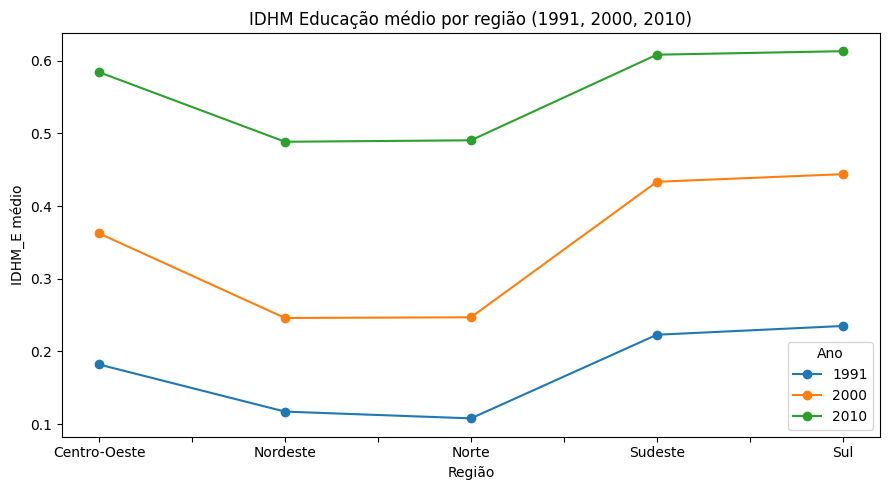

In [5]:
import matplotlib.pyplot as plt
evolucao.T.plot(marker="o", figsize=(9, 5))
plt.title("IDHM Educação médio por região (1991, 2000, 2010)")
plt.ylabel("IDHM_E médio")
plt.xlabel("Região")
plt.legend(title="Ano")
plt.tight_layout()
plt.savefig("../images/07_bronze_idhm_educacao_regiao.png", dpi=120)
plt.show()


## 4. Conclusão desta checagem

- Dados carregam corretamente, cobrindo 5.330 municípios em 3 anos-base.
- IDHM_E (dimensão educação) mostra melhora ao longo do tempo em todas as
  regiões, com heterogeneidade regional persistente — consistente com as
  hipóteses da EDA da base simulada.
- Indicadores de analfabetismo (`T_ANALF*`) e frequência escolar
  (`T_FREQ*`) estão disponíveis por município e são candidatos diretos
  para enriquecer a base analítica da Fase 3.

## 5. Próximo passo: camada silver

- Selecionar o ano-base mais recente (2010) ou tratar a série temporal.
- Padronizar nomes de município/UF para permitir `join` com a base da
  Fase 2 (via código IBGE do município, se disponível na base Gold).
- Selecionar e renomear apenas os indicadores relevantes ao problema.
- Salvar resultado em `data/silver/atlas_desenvolvimento_humano.csv`.
